###  Librerías
**Importamos las librerías necesarias, asegurando compatibilidad con TensorFlow/Keras**.

In [51]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from matplotlib import pyplot as plt

# Configuración de estilo
plt.style.use('seaborn-v0_8')

###  Datos
**Utilizamos la misma base de datos art_daily_jumpsup.csv del conjunto Numenta Anomaly Benchmark (NAB).**

In [52]:
master_url_root = "https://raw.githubusercontent.com/numenta/NAB/master/data/"

df_small_noise_url_suffix = "artificialNoAnomaly/art_daily_small_noise.csv"
df_small_noise_url = master_url_root + df_small_noise_url_suffix
df_small_noise = pd.read_csv(df_small_noise_url, parse_dates=True, index_col="timestamp")

df_daily_jumpsup_url_suffix = "artificialWithAnomaly/art_daily_jumpsup.csv"
df_daily_jumpsup_url = master_url_root + df_daily_jumpsup_url_suffix
df_daily_jumpsup = pd.read_csv(df_daily_jumpsup_url, parse_dates=True, index_col="timestamp")

In [53]:
print(df_small_noise.head())
print(df_daily_jumpsup.head())

                         value
timestamp                     
2014-04-01 00:00:00  18.324919
2014-04-01 00:05:00  21.970327
2014-04-01 00:10:00  18.624806
2014-04-01 00:15:00  21.953684
2014-04-01 00:20:00  21.909120
                         value
timestamp                     
2014-04-01 00:00:00  19.761252
2014-04-01 00:05:00  20.500833
2014-04-01 00:10:00  19.961641
2014-04-01 00:15:00  21.490266
2014-04-01 00:20:00  20.187739


### Visualización de los datos

**Serie sin anomalías**

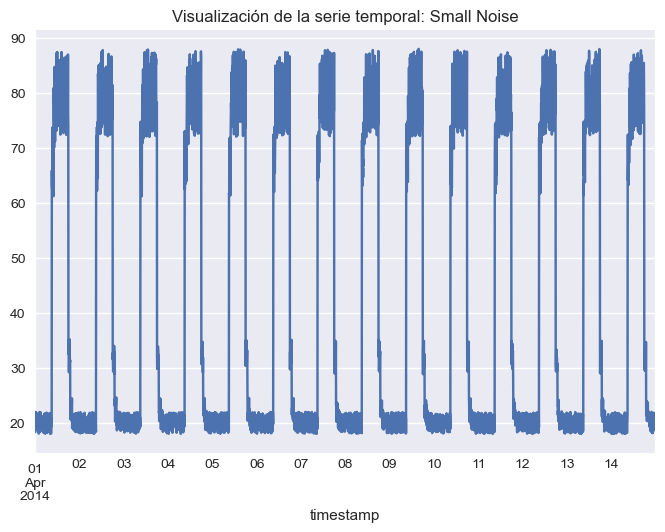

In [54]:
fig, ax = plt.subplots()
df_small_noise.plot(legend=False, ax=ax)
plt.title("Visualización de la serie temporal: Small Noise")
plt.show()

**Serie con Anomalías**

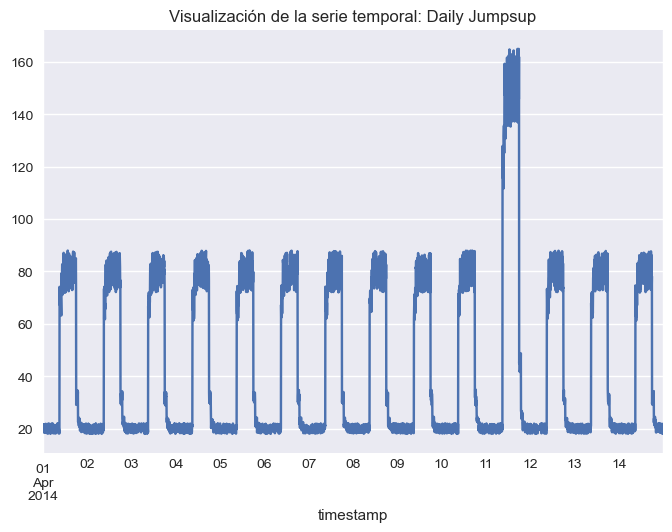

In [55]:
fig, ax = plt.subplots()
df_daily_jumpsup.plot(legend=False, ax=ax)
plt.title("Visualización de la serie temporal: Daily Jumpsup")
plt.show()

### Preprocesamiento.

Preparar datos de entrenamiento

Normalizamos los datos de entrenamiento para que tengan media 0 y desviación estándar 1. Luego creamos secuencias de tiempo.

In [56]:
# 1. Normalización
training_mean = df_small_noise.mean()
training_std = df_small_noise.std()
df_training_value = (df_small_noise - training_mean) / training_std
print("Número de ejemplos de entrenamiento:", len(df_training_value))

Número de ejemplos de entrenamiento: 4032


In [57]:
# 2. Creación de secuencias
TIME_STEPS = 288

# Generated training sequences for use in the model.
def create_sequences(values, time_steps=TIME_STEPS):
    output = []
    for i in range(len(values) - time_steps + 1):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)

x_train = create_sequences(df_training_value.values)
print("Training input shape: ", x_train.shape)
print(f"Forma de los datos de entrenamiento (LSTM Input): {x_train.shape}")

Training input shape:  (3745, 288, 1)
Forma de los datos de entrenamiento (LSTM Input): (3745, 288, 1)


### Construcción del modelo

**Explicación Matemática del Modelo**

El funcionamiento interno de nuestra red se puede describir como un **flujo de compresión y reconstrucción** dividido en cinco etapas clave.

---

**1. Compresión (Encoder)**

En la primera etapa, la capa **LSTM** procesa paso a paso toda la secuencia de entrada $( X )$.  
Lo interesante aquí es que configuramos la red para que descarte las salidas intermedias y conserve únicamente el **último estado oculto** $(( h_{288} ))$.

Al hacer esto, obligamos al modelo a **resumir toda la información** de la ventana temporal de **288 pasos** en un único **vector latente comprimido** $( z )$ de tamaño **32**:

$
z = \text{LSTM}_{enc}(X)
$

---

$2. Adaptación Temporal (RepeatVector)$

Como el vector latente $( z )$ es **estático** (no tiene dimensión temporal) y el decodificador necesita trabajar **secuencia a secuencia**, utilizamos un *puente*.

Simplemente copiamos el vector $( z )$ **288 veces** para recrear la estructura temporal necesaria:

$
Z_{seq} = [z, z, \dots, z]_{288 \text{ veces}}
$

---
**3. Reconstrucción (Decoder)**

Ahora, la segunda capa **LSTM** toma esta secuencia repetida y empieza a procesarla.  
A diferencia de la primera etapa, aquí sí le pedimos a la red que genere una **salida para cada instante de tiempo**, creando una nueva secuencia de estados ocultos $( \hat{H} )$, que representa la versión *recuperada* de los datos:

$
\hat{H} = \text{LSTM}_{dec}(Z_{seq})
$

---

$4. Proyección Final$

Para traducir esos estados internos de la red a **valores reales** (por ejemplo, el valor original de la serie), aplicamos una **transformación lineal** a cada paso de tiempo por igual.

Esto se realiza mediante una **capa densa distribuida temporalmente**:

$
\hat{x}_t = W \cdot \hat{h}_t + b
$

---

**5. Objetivo del Entrenamiento**

Todo el sistema aprende ajustando sus pesos para **minimizar el error** entre la entrada real y la reconstrucción generada por el modelo.

Matemáticamente, buscamos minimizar el **Error Cuadrático Medio (MSE)**:

$
J = \frac{1}{288} \sum_{t=1}^{288} (x_t - \hat{x}_t)^2
$

---

### Conclusión

El modelo actúa como un **“embudo”**.  
Al forzar a los datos a pasar por una representación muy pequeña (un vector de dimensión **32**), el sistema solo puede retener los **patrones principales y estructurales** de la serie.

Cualquier **ruido o anomalía** que no encaje en ese patrón principal tiende a **perderse en la reconstrucción**, lo cual es precisamente lo que permite **detectar fallos o comportamientos anómalos**.


In [58]:
model = tf.keras.Sequential([
    
    # Definimos la entrada con la forma de nuestras secuencias (288 pasos, 1 variable)
    layers.Input(shape=(x_train.shape[1], x_train.shape[2])),

    # Encoder: Usamos LSTM para capturar la memoria de la serie.
    # Al poner return_sequences=False, comprimimos toda la información en un solo vector latente.
    layers.LSTM(
        units=32, 
        activation='tanh', 
        return_sequences=False
    ),

    # Añadimos Dropout para evitar que el modelo se aprenda los datos de memoria (overfitting)
    layers.Dropout(rate=0.2),

    # Puente: Repetimos el vector latente 288 veces.
    # Esto es necesario para que el Decoder tenga una entrada para cada paso de tiempo que debe reconstruir.
    layers.RepeatVector(x_train.shape[1]),

    # Decoder: Otra capa LSTM que recibe la secuencia repetida.
    # Con return_sequences=True, generamos una salida para cada punto de la serie temporal.
    layers.LSTM(
        units=32, 
        activation='tanh', 
        return_sequences=True
    ),

    # Segunda capa de Dropout antes de la salida final
    layers.Dropout(rate=0.2),

    # Salida: Usamos TimeDistributed para aplicar una capa Densa a cada paso de tiempo individualmente.
    # Esto nos devuelve la serie reconstruida con la misma forma que la entrada.
    layers.TimeDistributed(layers.Dense(units=x_train.shape[2]))
])

# Compilamos usando el optimizador Adam y el error cuadrático medio (MSE)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector_3 (RepeatVector)       │ (None, 288, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 288, 32)             │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 288, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 288, 1)              │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

Entrenamos el modelo utilizando únicamente los datos **sin anomalías** (`df_small_noise`), de modo que el **LSTM-Autoencoder** aprenda el comportamiento **normal** de la serie temporal

In [59]:
history = model.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, mode="min")
    ],
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 472ms/step - loss: 1.0008 - val_loss: 1.0021
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - loss: 0.9836 - val_loss: 0.9494
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - loss: 0.9354 - val_loss: 0.9290
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - loss: 0.9087 - val_loss: 0.8957
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 385ms/step - loss: 0.8869 - val_loss: 0.8876
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 426ms/step - loss: 0.8559 - val_loss: 0.8537
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 396ms/step - loss: 0.8334 - val_loss: 0.8253
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 397ms/step - loss: 0.8676 - val_loss: 0.8639
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 415ms/step - loss: 0.8366 - val_loss: 0.8217
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 399ms/step - loss: 0.8048 - val_loss: 0.8031
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 399ms/step - loss: 0.7871 - val_loss: 0.7328
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 11

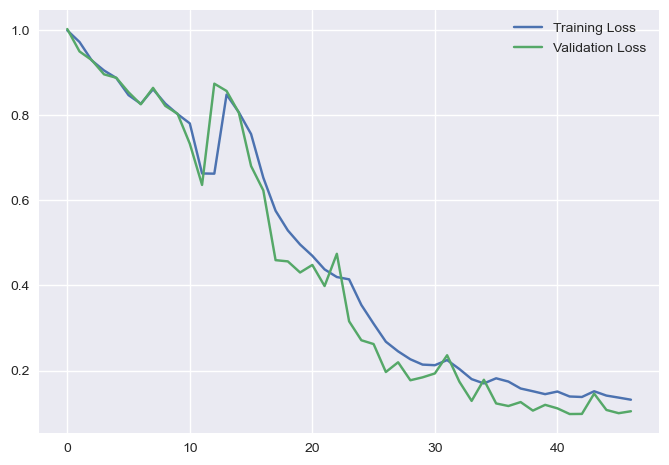

In [60]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()

## Detectando anomalías

Detectaremos anomalías determinando qué tan bien nuestro modelo puede reconstruir los datos de entrada.

1. Calcular la pérdida MAE en las muestras de entrenamiento.
2. Encontrar el valor máximo de la pérdida MAE. Este es el peor desempeño de nuestro modelo al intentar reconstruir una muestra. Usaremos este valor como el **umbral** para la detección de anomalías.
3. Si la pérdida de reconstrucción para una muestra es mayor que este valor **umbral**, entonces podemos inferir que el modelo está observando un patrón con el que no está familiarizado. Etiquetaremos esta muestra como una **anomalía**.



118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step


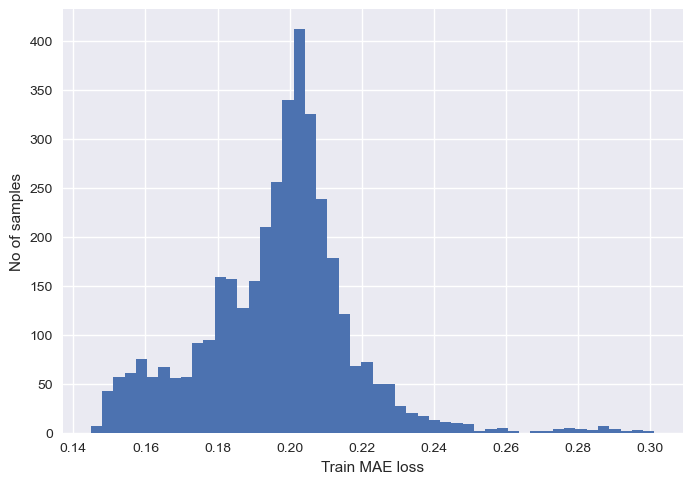

Reconstrucción del umbral de error:  0.30117676619187894


In [61]:
# Obtenemos el MAE en los datos de entrenamiento
x_train_pred = model.predict(x_train)
train_mae_loss = np.mean(np.abs(x_train_pred - x_train), axis=1)

plt.hist(train_mae_loss, bins=50)
plt.xlabel("Train MAE loss")
plt.ylabel("No of samples")
plt.show()

# Definimos el umbral como el máximo error encontrado en el entrenamiento
threshold = np.max(train_mae_loss)
print("Reconstrucción del umbral de error: ", threshold)

### Comparar reconstrucción

Veamos cómo nuestro modelo ha reconstruido la primera muestra. Esta corresponde a los **288 pasos de tiempo del día 1** de nuestro conjunto de entrenamiento

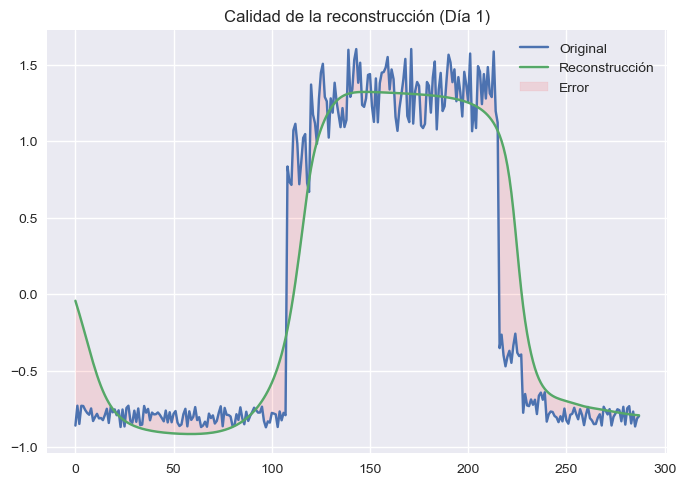

In [62]:
# Verificamos cómo aprendió la primera secuencia
plt.plot(x_train[0], label='Original')
plt.plot(x_train_pred[0], label='Reconstrucción')
plt.fill_between(np.arange(288), x_train[0].flatten(), x_train_pred[0].flatten(), color='red', alpha=0.1, label='Error')
plt.legend()
plt.title("Calidad de la reconstrucción (Día 1)")
plt.show()

 Interpretación de la Gráfica

### ¿Qué representa cada elemento?

- **Línea Azul (Original):**  
  Son los datos reales.  
  
- **Línea Naranja / Verde (Reconstrucción):**  
  Es lo que el modelo **LSTM cree que vio**.  
  El modelo tomó los datos, los comprimió en el **vector latente** y luego intentó *“redibujarlos”* de memoria.

- **Sombra Roja/rosada (Error):**  
  Representa la **diferencia entre ambas líneas**, es decir, el error de reconstrucción.

### Preparación de los datos test

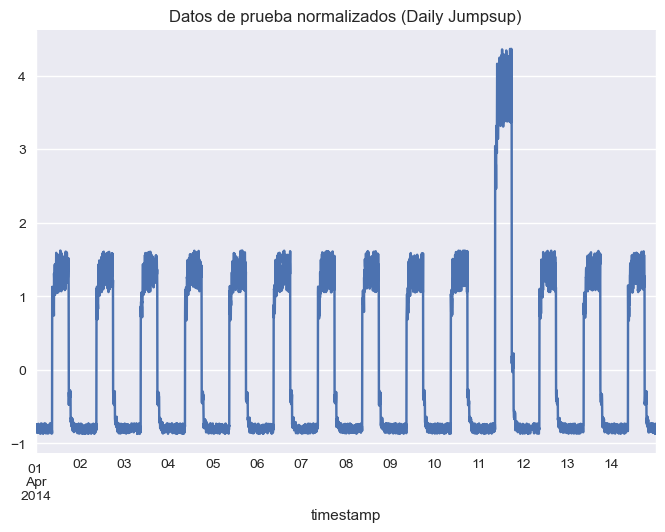

Test input shape:  (3745, 288, 1)


In [63]:
# Normalizamos los datos de prueba usando las estadísticas del entrenamiento
df_test_value = (df_daily_jumpsup - training_mean) / training_std

# Visualizamos los datos normalizados
fig, ax = plt.subplots()
df_test_value.plot(legend=False, ax=ax)
plt.title("Datos de prueba normalizados (Daily Jumpsup)")
plt.show()

# Creamos las secuencias (ventanas de tiempo) para alimentar el LSTM
x_test = create_sequences(df_test_value.values)
print("Test input shape: ", x_test.shape)

### Detectar anomalías en los datos de prueba

Calculamos el error de reconstrucción (MAE) para el conjunto de prueba. Si el error en una muestra supera nuestro **umbral** definido anteriormente, la marcamos como una anomalía.

118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


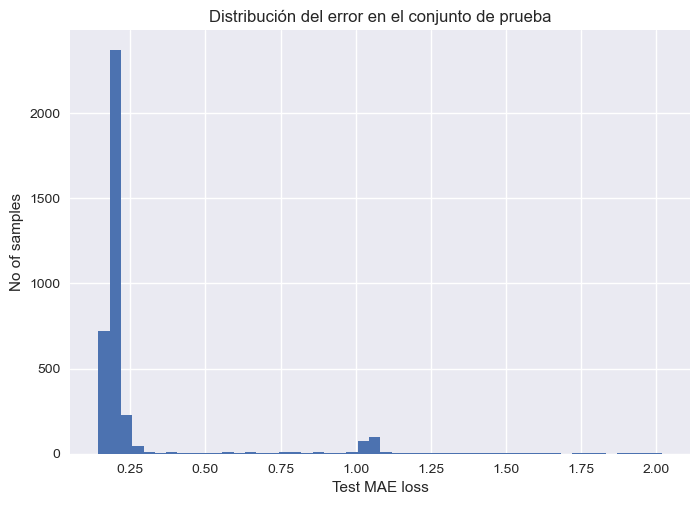

Número de muestras anómalas detectadas:  381
Índices de las muestras anómalas:  (array([ 505,  793, 2706, 2707, 2708, 2709, 2710, 2711, 2712, 2713, 2714,
       2715, 2716, 2717, 2718, 2719, 2720, 2721, 2722, 2723, 2724, 2725,
       2726, 2727, 2728, 2729, 2730, 2731, 2732, 2733, 2734, 2735, 2736,
       2737, 2738, 2739, 2740, 2741, 2742, 2743, 2744, 2745, 2746, 2747,
       2748, 2749, 2750, 2751, 2752, 2753, 2754, 2755, 2756, 2757, 2758,
       2759, 2760, 2761, 2762, 2763, 2764, 2765, 2766, 2767, 2768, 2769,
       2770, 2771, 2772, 2773, 2774, 2775, 2776, 2777, 2778, 2779, 2780,
       2781, 2782, 2783, 2784, 2785, 2786, 2787, 2788, 2789, 2790, 2791,
       2792, 2793, 2794, 2795, 2796, 2797, 2798, 2799, 2800, 2801, 2802,
       2803, 2804, 2805, 2806, 2807, 2808, 2809, 2810, 2811, 2812, 2813,
       2814, 2815, 2816, 2817, 2818, 2819, 2820, 2821, 2822, 2823, 2824,
       2825, 2826, 2827, 2828, 2829, 2830, 2831, 2832, 2833, 2834, 2835,
       2836, 2837, 2838, 2839, 2840, 2841, 

In [65]:
x_test_pred = model.predict(x_test)
test_mae_loss = np.mean(np.abs(x_test_pred - x_test), axis=1)
test_mae_loss = test_mae_loss.reshape((-1))


plt.hist(test_mae_loss, bins=50)
plt.xlabel("Test MAE loss")
plt.ylabel("No of samples")
plt.title("Distribución del error en el conjunto de prueba")
plt.show()

# 4. Detectar las anomalías comparando con el umbral
anomalies = test_mae_loss > threshold
print("Número de muestras anómalas detectadas: ", np.sum(anomalies))
print("Índices de las muestras anómalas: ", np.where(anomalies))

#### El Histograma de Error (Test MAE Loss)

- Esta gráfica muestra la **distribución de los errores** que cometió el modelo en el **conjunto de prueba**.

##### Lo que se observa

- **Una gran montaña de barras a la izquierda (cerca de 0):**  
  Representa todos los **datos normales** que el modelo pudo reconstruir correctamente.

- **Unas pocas barras pequeñas (o una sola) muy alejadas hacia la derecha:**  
  Corresponden a los datos donde el modelo **“se confundió”** y produjo un **error alto**.


### Visualización final de anomalías

Mapeamos las secuencias detectadas como anómalas de vuelta a los índices de tiempo originales y visualizamos el resultado sobre la serie temporal completa.

In [66]:
anomalous_data_indices = []
for data_idx in range(TIME_STEPS - 1, len(df_test_value) - TIME_STEPS + 1):
    if np.all(anomalies[data_idx - TIME_STEPS + 1 : data_idx]):
        anomalous_data_indices.append(data_idx)

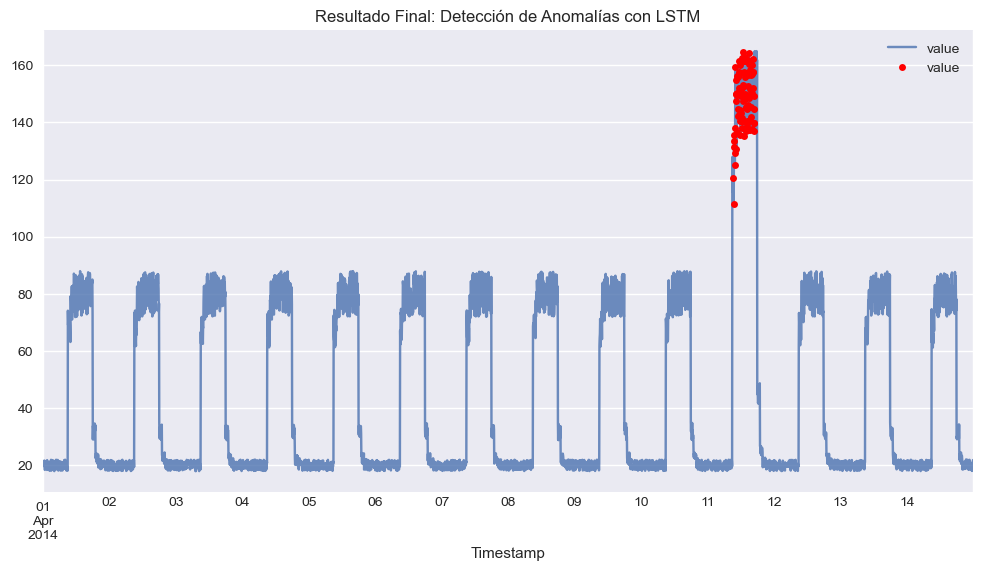

In [67]:
df_subset = df_daily_jumpsup.iloc[anomalous_data_indices]
fig, ax = plt.subplots(figsize=(12, 6))
df_daily_jumpsup.plot(legend=False, ax=ax, alpha=0.8, label='Datos Originales')
df_subset.plot(legend=False, ax=ax, color="r", style=".", markersize=10, label='Anomalía Detectada')
plt.title("Resultado Final: Detección de Anomalías con LSTM")
plt.xlabel("Timestamp")
plt.legend()
plt.show()

 ### Comparación de Resultados: LSTM vs. CNN (Clase)

Al comparar nuestro modelo **LSTM-Autoencoder** con el modelo **Convolucional (CNN)** visto en clase, observamos:

1.  **Eficacia:** Ambos modelos lograron minimizar el error de reconstrucción (MSE) y converger a una solución estable, detectando exitosamente la anomalía del "salto".
2.  **Arquitectura:**
    * "El modelo de clase (CNN) es muy rápido porque analiza los datos mirando solo pequeños fragmentos a la vez. Sin embargo, esto limita su visión: es como mirar a través de una ventana pequeña, por lo que le cuesta ver el contexto completo de lo que pasó hace mucho tiempo.".
    * El modelo **LSTM** (Reto IV) procesa la información secuencialmente manteniendo una "memoria" del pasado.
3.   **Conclusión:** Aunque es cierto que la LSTM tarda más en entrenarse y consume más recursos, vale la pena por su 'memoria'. Al ser capaz de recordar patrones de hace mucho tiempo, se vuelve una herramienta mucho más confiable que la CNN básica para datos complejos, demostrando que es una excelente alternativa